In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_train_featured.csv')
test_df = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_test_featured.csv')

In [3]:
train_df_pca = pd.read_csv('../results/outputs/PCA/pca_train.csv')
test_df_pca = pd.read_csv('../results/outputs/PCA/pca_test.csv')

In [4]:
train_df.shape

(880, 25)

In [5]:
train_df_pca.shape

(880, 3)

In [6]:
#splitting data

In [7]:
feature_cols = [c for c in train_df.columns if c != "target"]

X_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

In [8]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

In [10]:
from sklearn.metrics import accuracy_score, f1_score


model = MLPClassifier(random_state=42, max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(x_test)

y_pred_train = model.predict(X_train)


acc = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train, y_pred_train)
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy: {acc:.4f}")
print(f"Training Accuracy: {acc_train:.4f}")
print(f"F1 macro: {f1:.4f}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8864
Training Accuracy: 1.0000
F1 macro: 0.8860
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        74
           1       0.86      0.93      0.89        72
           2       0.91      0.91      0.91        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220

[[61  8  5]
 [ 3 67  2]
 [ 4  3 67]]


In [ ]:
#accuracy 0.88 means model geanaralize well

#moving on check PCA dataset

In [12]:
feature_cols_pca = [c for c in train_df_pca.columns if c != "target"]

X_train_pca = train_df_pca[feature_cols_pca]
y_train_pca = train_df_pca["target"]

X_test_pca = test_df_pca[feature_cols_pca]
y_test_pca = test_df_pca["target"]

In [13]:
model_pca = MLPClassifier(random_state=42, max_iter=500)
model_pca.fit(X_train_pca, y_train_pca)
y_pred_pca = model_pca.predict(X_test_pca)

y_pred_train_pca = model_pca.predict(X_train_pca)


acc_pca = accuracy_score(y_test_pca, y_pred_pca)
acc_train_pca = accuracy_score(y_train_pca, y_pred_train_pca)
f1_pca = f1_score(y_test_pca, y_pred_pca, average="macro")

print(f"Accuracy: {acc_pca:.4f}")
print(f"Training Accuracy: {acc_train_pca:.4f}")
print(f"F1 macro: {f1_pca:.4f}")
print(classification_report(y_test_pca, y_pred_pca))
print(confusion_matrix(y_test_pca, y_pred_pca))

Accuracy: 0.9045
Training Accuracy: 0.8864
F1 macro: 0.9050
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        74
           1       0.96      0.89      0.92        72
           2       0.87      0.92      0.89        74

    accuracy                           0.90       220
   macro avg       0.91      0.90      0.90       220
weighted avg       0.91      0.90      0.90       220

[[67  2  5]
 [ 3 64  5]
 [ 5  1 68]]


In [ ]:
#accuracy is same but but f1 score is better the for sticking to PCA dataset

#moving to hyperparameter tuning

In [15]:
param_grid = {
    "hidden_layer_sizes": [(50,), (100,), (50, 50), (100, 50), (100, 100)],
    "activation": ["relu", "tanh"],
    "solver": ["adam"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "max_iter": [500],
    "early_stopping": [True],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_pca = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
)

grid_pca.fit(X_train_pca, y_train_pca)

best_model_pca = grid_pca.best_estimator_
y_pred_pca = best_model_pca.predict(X_test_pca)

acc_pca_t = accuracy_score(y_test_pca, y_pred_pca)
f1_pca_t = f1_score(y_test_pca, y_pred_pca, average="macro")

print("Best params:", grid_pca.best_params_)
print("Best CV f1_macro (train):", grid_pca.best_score_)
print(f"Test accuracy: {acc_pca_t:.4f}")
print(f"Test F1 macro: {f1_pca_t:.4f}")
print(classification_report(y_test_pca, y_pred_pca))
print(confusion_matrix(y_test_pca, y_pred_pca))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params: {'activation': 'tanh', 'alpha': 0.0001, 'early_stopping': True, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.001, 'max_iter': 500, 'solver': 'adam'}
Best CV f1_macro (train): 0.8880736131310473
Test accuracy: 0.9000
Test F1 macro: 0.9016
              precision    recall  f1-score   support

           0       0.94      0.84      0.89        74
           1       1.00      0.89      0.94        72
           2       0.80      0.97      0.88        74

    accuracy                           0.90       220
   macro avg       0.91      0.90      0.90       220
weighted avg       0.91      0.90      0.90       220

[[62  0 12]
 [ 2 64  6]
 [ 2  0 72]]


In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

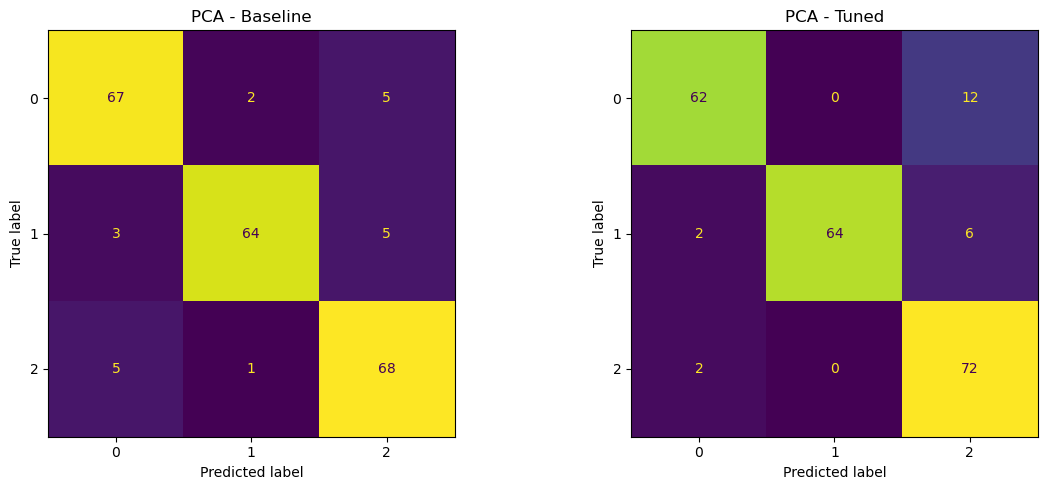

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_base_pca = confusion_matrix(y_test_pca, model_pca.predict(X_test_pca))
cm_tuned_pca = confusion_matrix(y_test_pca, y_pred_pca)

ConfusionMatrixDisplay(cm_base_pca).plot(ax=axes[0], colorbar=False)
axes[0].set_title("PCA - Baseline")

ConfusionMatrixDisplay(cm_tuned_pca).plot(ax=axes[1], colorbar=False)
axes[1].set_title("PCA - Tuned")

plt.tight_layout()
plt.show()

In [18]:
import joblib

joblib.dump(best_model_pca, "../results/model_trained_files/mlp_tuned.pkl")

['../results/model_trained_files/mlp_tuned.pkl']